In [2]:
import os
import geopandas as gpd

gdf = gpd.read_file(r"D:\Datasets\Imagenes Satelitales\Estados Unidos\NY State Imagery\NYC\boro_bronx_sp06\lot6_nyc_liz_06.shp")
gdf.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [3]:
gdf#.to_crs("EPSG:4326")

,SPEC,COUNTY,Sublot,IMAGE,XMIN,YMIN,XMAX,YMAX,geometry
0,Selective True Ortho,Bronx,2,000262.jp2,1000000,262500,1002500,265000,"POLYGON ((1000000 265000, 1002500 265000, 1002..."
1,Selective True Ortho,New York,2,000260.jp2,1000000,260000,1002500,262500,"POLYGON ((1000000 262500, 1002500 262500, 1002..."
2,Selective True Ortho,New York,2,000257.jp2,1000000,257500,1002500,260000,"POLYGON ((1000000 260000, 1002500 260000, 1002..."
3,Selective True Ortho,New York,2,997255.jp2,997500,255000,1000000,257500,"POLYGON ((997500 257500, 1000000 257500, 10000..."
4,Selective True Ortho,New York,2,995252.jp2,995000,252500,997500,255000,"POLYGON ((995000 255000, 997500 255000, 997500..."
...,...,...,...,...,...,...,...,...,...
2044,Selective True Ortho,Bronx,2,025230.jp2,1025000,230000,1027500,232500,"POLYGON ((1025000 232500, 1027500 232500, 1027..."
2045,Selective True Ortho,Bronx,2,010227.jp2,1010000,227500,1012500,230000,"POLYGON ((1010000 230000, 1012500 230000, 1012..."
2046,Selective True Ortho,Bronx,2,012227.jp2,1012500,227500,1015000,230000,"POLYGON ((1012500 230000, 1015000 230000, 1015..."
2047,Selective True Ortho,Bronx,2,015227.jp2,1015000,227500,1017500,230000,"POLYGON ((1015000 230000, 1017500 230000, 1017..."


In [72]:
import os
import zipfile
import glob
from pathlib import Path
import geopandas as gpd
import rioxarray
from osgeo import gdal
from tqdm import tqdm

def process_ny_imagery(folder_path, shapefile_name):
    """
    1. Reads the Shapefile to find image names.
    2. Unzips the corresponding .jp2 files.
    3. Creates a VRT mosaic.
    4. Returns a lazy-loaded Xarray object.
    """
    base_dir = Path(folder_path)
    shp_path = base_dir / shapefile_name
    
    # Define where to put extracted images (can be a subfolder to keep things clean)
    extract_dir = base_dir / "extracted_jp2"
    extract_dir.mkdir(exist_ok=True)
    
    # --- Step 1: Read the Shapefile Index ---
    print(f"📖 Reading index: {shp_path}")
    try:
        gdf = gpd.read_file(shp_path)
        # Get the list of expected .jp2 filenames from the 'IMAGE' column
        image_list = gdf['IMAGE'].tolist()
        print(f"   Found {len(image_list)} images in the index.")
    except Exception as e:
        print(f"❌ Error reading Shapefile: {e}")
        return None

    # --- Step 2: Unzip the specific files ---
    print("🚀 Extracting files...")
    
    extracted_files = []
    
    # We loop through the list from the shapefile to ensure we match the data
    for image_name in tqdm(image_list, desc="Unzipping"):
        # Construct the zip filename. Assumption: "000262.jp2" is inside "000262.zip"
        zip_name = image_name.replace('.jp2', '.zip') 
        zip_path = base_dir / zip_name
        
        target_jp2 = extract_dir / image_name
        
        # Track this path for the VRT later
        extracted_files.append(str(target_jp2))

        # Skip if already extracted
        if target_jp2.exists():
            continue
            
        if not zip_path.exists():
            # Try finding the zip with different casing or prefix if strict matching fails
            # (Optional safeguard, skipping for now based on your description)
            print(f"⚠️ Warning: Zip file not found for {image_name}")
            continue

        try:
            with zipfile.ZipFile(zip_path, 'r') as zf:
                # We only want the .jp2 and the .j2w (world file)
                # The .j2w is crucial for the grid alignment!
                files_to_extract = [f for f in zf.namelist() if f.lower().endswith(('.jp2', '.j2w', '.aux'))]
                
                for file in files_to_extract:
                    # Extract to the specific folder
                    zf.extract(file, extract_dir)
        except zipfile.BadZipFile:
            print(f"❌ Corrupt zip file: {zip_path}")

    # --- Step 3: Create the Virtual Mosaic (VRT) ---
    print("🗺️  Building VRT Mosaic...")
    vrt_path = base_dir / "mosaic.vrt"
    
    # Filter list to ensure files actually exist (in case of unzip errors)
    valid_files = [f for f in extracted_files if os.path.exists(f)]
    
    if not valid_files:
        print("❌ No valid images found to create mosaic.")
        return None

    # Build VRT
    # srcNodata=0 ensures that the empty space (since shape is not square) 
    # is treated as transparent/nodata rather than black.
    vrt_options = gdal.BuildVRTOptions(resampleAlg='nearest', addAlpha=False, srcNodata=0)
    gdal.BuildVRT(str(vrt_path), valid_files, options=vrt_options)
    print(f"✅ VRT created at: {vrt_path}")

    # --- Step 4: Open as Xarray ---
    print("📡 Loading into Xarray (Lazy)...")
    
    # chunks is mandatory for lazy loading
    da = rioxarray.open_rasterio(vrt_path, chunks={'x': 2048, 'y': 2048})
    
    # --- Handle the 4-Band Issue (Infrared) ---
    if da.rio.count == 4:
        print("⚠️ 4 Bands detected. Dropping Band 4 (Infrared) to keep RGB.")
        da = da.sel(band=[1, 2, 3])
        
    print(f"✅ Final Data Shape: {da.shape}")
    return da

# --- Usage ---
# folder = r"C:\Your\Path\To\Data"
# shp_name = "your_index_file.shp"
# xarray_data = process_ny_imagery(folder, shp_name)

ModuleNotFoundError: No module named 'osgeo'

In [ ]:
gdf[gdf["COUNTY"]=="Bronx"]

,SPEC,COUNTY,Sublot,IMAGE,XMIN,YMIN,XMAX,YMAX,geometry
0,Selective True Ortho,Bronx,2,000262.jp2,1000000,262500,1002500,265000,"POLYGON ((1000000 265000, 1002500 265000, 1002..."
1292,Attachment A Half-foot,Bronx,2,997275.jp2,997500,275000,1000000,277500,"POLYGON ((997500 277500, 1000000 277500, 10000..."
1293,Attachment A Half-foot,Bronx,2,000275.jp2,1000000,275000,1002500,277500,"POLYGON ((1000000 277500, 1002500 277500, 1002..."
1294,Attachment A Half-foot,Bronx,2,002275.jp2,1002500,275000,1005000,277500,"POLYGON ((1002500 277500, 1005000 277500, 1005..."
1295,Attachment A Half-foot,Bronx,2,997272.jp2,997500,272500,1000000,275000,"POLYGON ((997500 275000, 1000000 275000, 10000..."
...,...,...,...,...,...,...,...,...,...
2044,Selective True Ortho,Bronx,2,025230.jp2,1025000,230000,1027500,232500,"POLYGON ((1025000 232500, 1027500 232500, 1027..."
2045,Selective True Ortho,Bronx,2,010227.jp2,1010000,227500,1012500,230000,"POLYGON ((1010000 230000, 1012500 230000, 1012..."
2046,Selective True Ortho,Bronx,2,012227.jp2,1012500,227500,1015000,230000,"POLYGON ((1012500 230000, 1015000 230000, 1015..."
2047,Selective True Ortho,Bronx,2,015227.jp2,1015000,227500,1017500,230000,"POLYGON ((1015000 230000, 1017500 230000, 1017..."


In [ ]:
files = os.listdir(r"D:\Datasets\Imagenes Satelitales\Estados Unidos\NY State Imagery\NYC")
files = [f for f in files if ".zip" in f]
files

borough_names = ["bronx", "brooklyn", "manhattan", "queens", "staten_island"]
# Create the dictionary
borough_dict = {}

for boro in borough_names:
    borough_dict[boro] = []
    for filename in files:
        if boro in filename:
            borough_dict[boro].append(filename)

borough_dict

{'bronx': ['boro_bronx_sp06.zip',
  'boro_bronx_sp08.zip',
  'boro_bronx_sp10.zip',
  'boro_bronx_sp12.zip',
  'boro_bronx_sp14.zip',
  'boro_bronx_sp16.zip',
  'boro_bronx_sp18.zip',
  'boro_bronx_sp20.zip',
  'boro_bronx_sp22.zip',
  'boro_bronx_sp24.zip'],
 'brooklyn': ['boro_brooklyn_sp06.zip',
  'boro_brooklyn_sp08.zip',
  'boro_brooklyn_sp10.zip',
  'boro_brooklyn_sp12.zip',
  'boro_brooklyn_sp14.zip',
  'boro_brooklyn_sp16.zip',
  'boro_brooklyn_sp18.zip',
  'boro_brooklyn_sp20.zip',
  'boro_brooklyn_sp22.zip',
  'boro_brooklyn_sp24.zip'],
 'manhattan': ['boro_manhattan_sp06.zip',
  'boro_manhattan_sp08.zip',
  'boro_manhattan_sp10.zip',
  'boro_manhattan_sp12.zip',
  'boro_manhattan_sp14.zip',
  'boro_manhattan_sp16.zip',
  'boro_manhattan_sp18.zip',
  'boro_manhattan_sp20.zip',
  'boro_manhattan_sp22.zip',
  'boro_manhattan_sp24.zip'],
 'queens': ['boro_queens_sp06.zip',
  'boro_queens_sp08.zip',
  'boro_queens_sp10.zip',
  'boro_queens_sp12.zip',
  'boro_queens_sp14.zip',
  '

In [ ]:
borough_translation = {
    'bronx': 'Bronx',
    'manhattan':'New York',
    'staten_island': 'Richmond',
    'brooklyn': 'Kings',
    'queens': 'Queens',
}

In [1]:
import os
import zipfile
import glob
from pathlib import Path
import geopandas as gpd
import rioxarray
# from osgeo import gdal
from tqdm import tqdm

for boro, f_list in borough_dict.items():

    for file in f_list:
        base_dir = rf"D:\Datasets\Imagenes Satelitales\Estados Unidos\NY State Imagery\NYC\{file}"
        shp_path = rf"{base_dir}\lot6_nyc_liz_06.shp"

        # Define where to put extracted images (can be a subfolder to keep things clean)
        extract_dir = rf"{base_dir}\extracted_jp2"
        os.makedirs(extract_dir, exist_ok=True)

        # --- Step 1: Read the Shapefile Index ---
        print(f"📖 Reading index: {shp_path}")
        try:
            gdf = gpd.read_file(shp_path)
            # Get the list of expected .jp2 filenames from the 'IMAGE' column
            image_list = gdf[gdf["COUNTY"]=="Bronx"]['IMAGE'].tolist()
            print(f"   Found {len(image_list)} images in the index.")

        except Exception as e:
            raise ValueError(f"❌ Error reading Shapefile: {e}")

        # --- Step 2: Unzip the specific files ---
        print("🚀 Extracting files...")

        extracted_files = []

        # We loop through the list from the shapefile to ensure we match the data
        for image_name in tqdm(image_list, desc="Unzipping"):
            # Construct the zip filename. Assumption: "000262.jp2" is inside "000262.zip"
            zip_name = image_name.replace('.jp2', '.zip') 
            zip_path = rf"{base_dir}\{zip_name}"
            
            target_jp2 = rf"{extract_dir}\{image_name}"
            
            # Track this path for the VRT later
            extracted_files.append(str(target_jp2))

            # Skip if already extracted
            if os.path.exists(target_jp2):
                continue
                
            if not os.path.exists(zip_path):
                # Try finding the zip with different casing or prefix if strict matching fails
                # (Optional safeguard, skipping for now based on your description)
                print(f"⚠️ Warning: Zip file not found for {image_name}")
                print(zip_name, zip_path)

            try:
                with zipfile.ZipFile(zip_path, 'r') as zf:
                    # We only want the .jp2 and the .j2w (world file)
                    # The .j2w is crucial for the grid alignment!
                    files_to_extract = [f for f in zf.namelist() if f.lower().endswith(('.jp2', '.j2w', '.aux'))]
                    
                    for file in files_to_extract:
                        # Extract to the specific folder
                        zf.extract(file, extract_dir)

            except zipfile.BadZipFile:
                print(f"❌ Corrupt zip file: {zip_path}")



NameError: name 'borough_dict' is not defined

In [ ]:
import os
import dask
import zipfile
import geopandas as gpd
import rioxarray
import xarray as xr
from pathlib import Path
from tqdm import tqdm
import shutil
import xarray as xr
import rioxarray
import numpy as np
from pathlib import Path
from dask.diagnostics import ProgressBar


def move_images(image_list, folder, output_folder):
    ''' All the images have the same 2006 shapefile. So we can move them all to a yearly folder and work with that! '''   
   
    # Add year to output_folder
    year = folder.name.split("_")[-1][-2:]
    output_folder = output_folder / year
    os.makedirs(output_folder, exist_ok=True)

    count = 0
    for jp2_name in tqdm(image_list, desc="Prep"):

        zip_name = jp2_name.replace(".jp2", ".zip")
        j2w_name = jp2_name.replace(".jp2", ".j2w")
        aux_name = jp2_name.replace(".jp2", ".aux")
        tab_name = jp2_name.replace(".jp2", ".tab")

        jp2_path = folder / jp2_name
        zip_path = folder / zip_name

        # If already extracted
        if jp2_path.exists():
            
            # Move to the output_folder
            for f in [jp2_name, j2w_name, aux_name, tab_name]:

                if (folder / f).exists():
                    shutil.move(folder / f, output_folder / f)

            count += 1
            continue
            
        # Unzip if missing
        elif zip_path.exists():
            try:
                with zipfile.ZipFile(zip_path, 'r') as zf:
                    # We need the jp2 and the world file (.j2w)
                    files = [f for f in zf.namelist() if f.lower().endswith(('.jp2', '.j2w', '.aux', '.tab'))]
                    for f in files:
                        zf.extract(f, output_folder / f)

                count += 1

            except Exception as e:
                print(f"❌ Error unzipping {zip_path}: {e}")

        else:
            continue

    if count == 0:
        print(f"❌ No images found in {folder}.")
        return
    
def load_mosaic(images_path):
    import concurrent.futures
    import rioxarray
    import xarray as xr
    from pathlib import Path
    from tqdm import tqdm
    import win32file

    print("Setting windows max file opening number...")
    print(f"Old limit: {win32file._getmaxstdio()}")
    win32file._setmaxstdio(8192)
    print(f"New limit: {win32file._getmaxstdio()}")

    os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR" # Don't scan directory contents
    os.environ["GDAL_NUM_THREADS"] = "1" # Disable GDAL's internal threading (let Dask handle it)
    os.environ["OPJ_NUM_THREADS"] = "1"  # Disable OpenJPEG threading
    os.environ["GDAL_CACHEMAX"] = "512"  # Increase cache size

    base_dir = Path(images_path)
    assert base_dir.exists(), f"Directory not found: {base_dir}"

    images = list(base_dir.glob("*.jp2"))
    if not images:
        print("❌ No .jp2 files found.")
        return None

    print(f"📡 Loading {len(images)} tiles into Xarray (Parallel Lazy)...")

    # --- Worker Function for Parallel Execution ---
    def open_single_image(p):
        try:
            # chunks={} activates Dask (lazy loading) - crucial!
            ds = rioxarray.open_rasterio(p, chunks={"x": 2500, "y": 2500})
            ds = ds.rio.write_nodata(0, inplace=False)
            ds = ds.astype("uint8")
            return ds
        except Exception as e:
            print(f"⚠️ Fail: {p.name} - {e}")
            return None

    datasets = []
    
    # --- Execute in Parallel ---
    # Max workers = 16 or 32 is usually the sweet spot for file headers.
    # Your Gen 5 SSD can handle way more, but Python overhead limits us.
    with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
        # map returns an iterator, so we wrap it in list() to force execution
        results = list(tqdm(executor.map(open_single_image, images), total=len(images), desc="Opening Headers"))

    # Remove failures (None)
    datasets = [ds for ds in results if ds is not None]

    # --- Step 3: Combine ---
    print("🧩 Stitching mosaic together (combine_by_coords)...")
    try:
        # This part is pure CPU (sorting coordinates) and cannot be easily parallelized
        mosaic = xr.combine_by_coords(datasets)
        print(f"✅ Mosaic Complete! Shape: {mosaic.shape}")
        return mosaic
    except ValueError as e:
        print(f"❌ Merge failed: {e}")
        return None
        
def convert_to_zarr(folder_path, output_file="nyc_imagery.zarr", client=None):
    """
    Converts the slow JP2 mosaic into a fast, chunked Zarr dataset.
    """
    from numcodecs import Blosc, Delta

    folder_path = Path(folder_path)
    output_file = Path(output_file)

    # Create the Lazy Virtual Mosaic
    print("⏳ Building virtual layer from JP2s...")
    mosaic = load_mosaic(folder_path)
    mosaic = mosaic.astype("uint8")

    if mosaic is None:
        return

    # We remove the _FillValue from the attributes so it doesn't conflict 
    # with the encoding settings during export.
    if "_FillValue" in mosaic.attrs:
        del mosaic.attrs["_FillValue"]
    

    # Ensure standard names for coordinates so tools generally recognize it
    if 'band' in mosaic.coords:
        mosaic.coords['band'] = np.array([1, 2, 3, 4]) # RGB-NIR
    
    mosaic.name = "value"
    
    print("✂️ Masking last 2 bits for higher compression...")
    mosaic = mosaic & 0xFC    

    # Export to Zarr
    # This is the heavy lifting step. It will read the JP2s and write the Zarr.
    print(f"💾 Exporting to {output_file}...")
    print("   (This will take a while, but only needs to be done once!)")

    # mosaic = mosaic.chunk({
    #     "band": 1,
    #     "y": 2048,
    #     "x": 2048,
    # })
    # Lossy compression (manual)
    # Clear any previous encoding info carried over from the JP2s
    mosaic.encoding = {}
    filters = [Delta(dtype="uint8")]
    compressor = Blosc(cname='zstd', clevel=5, shuffle=Blosc.BITSHUFFLE)
    mosaic.to_zarr(
        output_file, 
        mode='w', 
        compute=True,
        encoding={"value": {
            "dtype": "uint8",
            "compressor": compressor,
            "filters": filters,
            "_FillValue": 0
        }},
        write_empty_chunks=False,
        zarr_format=2 
    )

    print("✅ Done! Data is now in Zarr format.")
    return

# # --- Usage ---
# folder = r"D:\Datasets\Imagenes Satelitales\Estados Unidos\NY State Imagery\NYC\boro_bronx_sp10"
# shp = "lot6_nyc_liz_06.shp"

# # Run the conversion
# zarr_path = convert_to_zarr(folder, shp)


# Transform the raw folder of images to zarr
years = [
    # '08',
    # '10',
    # '12',
    '14',
    '16',
    '18',
    '20',
    '22',
    '24',
]

from IPython.display import display
from dask.distributed import Client, LocalCluster

# Configure the cluster explicitly for CPU-bound image work
# n_workers=8: Matches your physical cores (adjust based on your CPU)
# threads_per_worker=1: Ensures no GIL contention. 
# memory_limit='4GB': Prevents workers from eating all RAM.
cluster = LocalCluster(n_workers=3, threads_per_worker=1, memory_limit='8GB')
client = Client(cluster)
display(client)

for year in years:
    print("Process will be run on Dask client:")

    # Move from HDD (D) to Super Fast SSD (E)
    folder_path = rf"E:\Datasets\Imagenes Satelitales\New York City\NYC Images\{year}"
    output_file= rf"E:\Datasets\Imagenes Satelitales\New York City\nyc_20{year}.zarr"
    mosaic = convert_to_zarr(
        folder_path, 
        output_file,
        client
    )


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 22.35 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:62415,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:62434,Total threads: 1
Dashboard: http://127.0.0.1:62439/status,Memory: 5.59 GiB
Nanny: tcp://127.0.0.1:62418,


Process will be run on Dask client:
⏳ Building virtual layer from JP2s...
Setting windows max file opening number...
Old limit: 512
New limit: 8192
📡 Loading 2049 tiles into Xarray (Parallel Lazy)...


Opening Headers:  69%|██████▉   | 1409/2049 [00:16<00:07, 87.20it/s]


KeyboardInterrupt: 

In [14]:
# EXTRACTED_IMAGES = Path(r"D:\Datasets\Imagenes Satelitales\Estados Unidos\NY State Imagery\NYC\NYC Images")
# shp_path = EXTRACTED_IMAGES / "lot6_nyc_liz_06.shp"

# gdf = gpd.read_file(shp_path)
# image_list = gdf['IMAGE'].tolist()

# # Image folders
# root_path = r"D:\Datasets\Imagenes Satelitales\Estados Unidos\NY State Imagery\NYC"
# folders = os.listdir(root_path)
# folders = [f for f in folders if len(f.split("."))==1 and "boro_" in f]

# for folder in folders[3:]:

#     folder = Path(root_path) / folder
#     move_images(image_list, folder, EXTRACTED_IMAGES)


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:59553/status,
Dashboard: http://127.0.0.1:59553/status,Workers: 4
Total threads: 4,Total memory: 22.35 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:59554,Workers: 0
Dashboard: http://127.0.0.1:59553/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:59573,Total threads: 1
Dashboard: http://127.0.0.1:59577/status,Memory: 5.59 GiB
Nanny: tcp://127.0.0.1:59557,


Process will be run on Dask client:
⏳ Building virtual layer from JP2s...
Setting windows max file opening number...
Old limit: 8192
New limit: 8192
📡 Loading 2049 tiles into Xarray (Parallel Lazy)...


Opening Headers: 100%|██████████| 2049/2049 [00:33<00:00, 61.36it/s]


🧩 Stitching mosaic together (combine_by_coords)...
✅ Mosaic Complete! Shape: (4, 320000, 325000)
💾 Exporting to E:\Datasets\Imagenes Satelitales\New York City\nyc_2014.zarr...
   (This will take a while, but only needs to be done once!)


Task exception was never retrieved
future: <Task finished name='Task-1696777' coro=<Client._gather.<locals>.wait() done, defined at c:\Users\abbat\AppData\Local\Programs\Python\Python313\Lib\site-packages\distributed\client.py:2385> exception=AllExit()>
Traceback (most recent call last):
  File "c:\Users\abbat\AppData\Local\Programs\Python\Python313\Lib\site-packages\distributed\client.py", line 2394, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 

In [21]:
mosaic

<xarray.DataArray 'value' (band: 4, y: 320000, x: 325000)> Size: 416GB
dask.array<astype, shape=(4, 320000, 325000), dtype=uint8, chunksize=(4, 2500, 2500), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float64 3MB 9.075e+05 9.075e+05 ... 1.07e+06 1.07e+06
  * y            (y) float64 3MB 2.775e+05 2.775e+05 ... 1.175e+05 1.175e+05
    spatial_ref  int64 8B 0
  * band         (band) int64 32B 1 2 3 4
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [29]:
mosaic.isel(x=slice(0,1000), y=slice(0,1000)).to_dataset()

<xarray.Dataset> Size: 4MB
Dimensions:      (x: 1000, y: 1000, band: 4)
Coordinates:
  * x            (x) float64 8kB 9.075e+05 9.075e+05 ... 9.08e+05 9.08e+05
  * y            (y) float64 8kB 2.775e+05 2.775e+05 ... 2.77e+05 2.77e+05
    spatial_ref  int64 8B 0
  * band         (band) int64 32B 1 2 3 4
Data variables:
    value        (band, y, x) uint8 4MB dask.array<chunksize=(4, 1000, 1000), meta=np.ndarray>

In [41]:
mosaic.isel(x=slice(0,10000), y=slice(0,1000)).to_zarr(
    r"E:\Datasets\Imagenes Satelitales\New York City\test.zarr", 
    mode='w', 
    compute=True,
    encoding={"value": {
        "dtype": "uint8",
    }},
    write_empty_chunks=False 
)

In [43]:
test = xr.open_zarr(r"E:\Datasets\Imagenes Satelitales\New York City\test.zarr",
    mask_and_scale=False)
test

<xarray.Dataset> Size: 40MB
Dimensions:      (band: 4, y: 1000, x: 10000)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
    spatial_ref  int64 8B ...
  * x            (x) float64 80kB 9.075e+05 9.075e+05 ... 9.125e+05 9.125e+05
  * y            (y) float64 8kB 2.775e+05 2.775e+05 ... 2.77e+05 2.77e+05
Data variables:
    value        (band, y, x) uint8 40MB dask.array<chunksize=(4, 1000, 2500), meta=np.ndarray>

In [ ]:

os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR" # Don't scan directory contents
os.environ["GDAL_NUM_THREADS"] = "1" # Disable GDAL's internal threading (let Dask handle it)
os.environ["OPJ_NUM_THREADS"] = "1"  # Disable OpenJPEG threading
os.environ["GDAL_CACHEMAX"] = "512"  # Increase cache size

year = '08'
folder_path = rf"E:\Datasets\Imagenes Satelitales\New York City\NYC Images\{year}"

ds = load_mosaic(folder_path)

📡 Loading tiles into Xarray (Lazy)...


Opening:  46%|████▌     | 822/1778 [07:05<08:15,  1.93it/s]  


KeyboardInterrupt: 

In [ ]:

# ds = load_mosaic_parallel(folder_path)
# ds

# Test for checking if the zarr/xarray are good!

In [75]:
folder = r"E:\Datasets\Imagenes Satelitales\New York City\NYC Images\24"
# mosaic = load_mosaic(folder)
mosaic = load_mosaic_parallel(folder)


📡 Loading 1581 tiles into Xarray (Parallel Lazy)...


Opening Headers: 100%|██████████| 1581/1581 [00:18<00:00, 83.99it/s]


🧩 Stitching mosaic together (combine_by_coords)...
✅ Mosaic Complete! Shape: (4, 285000, 220000)


In [76]:
from dask.distributed import Client
from IPython.display import display

client = Client()
display(client)

mosaic.to_zarr(r"E:\Datasets\Imagenes Satelitales\New York City\test.zarr", mode="w")

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:60830/status,
Dashboard: http://127.0.0.1:60830/status,Workers: 5
Total threads: 20,Total memory: 31.60 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:60831,Workers: 0
Dashboard: http://127.0.0.1:60830/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:60856,Total threads: 4
Dashboard: http://127.0.0.1:60861/status,Memory: 6.32 GiB
Nanny: tcp://127.0.0.1:60834,


In [10]:
mosaic = xr.open_zarr(r"E:\Datasets\Imagenes Satelitales\New York City\nyc_2014.zarr")#.load()

In [11]:
mosaic

<xarray.Dataset> Size: 3TB
Dimensions:      (band: 4, y: 320000, x: 325000)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
    spatial_ref  int64 8B ...
  * x            (x) float64 3MB 9.075e+05 9.075e+05 ... 1.07e+06 1.07e+06
  * y            (y) float64 3MB 2.775e+05 2.775e+05 ... 1.175e+05 1.175e+05
Data variables:
    value        (band, y, x) float64 3TB dask.array<chunksize=(4, 2500, 2500), meta=np.ndarray>

In [79]:
image = mosaic.sel(x=slice(1025500, 1026500), y=slice(272000, 271000)).load()

In [82]:
image

<xarray.Dataset> Size: 128MB
Dimensions:                        (band: 4, y: 2000, x: 2000)
Coordinates:
  * band                           (band) int64 32B 1 2 3 4
  * x                              (x) float64 16kB 1.026e+06 ... 1.026e+06
  * y                              (y) float64 16kB 2.72e+05 ... 2.71e+05
Data variables:
    __xarray_dataarray_variable__  (band, y, x) float64 128MB 167.0 ... 232.0
    spatial_ref                    int64 8B 0

In [81]:
import earthpy.plot as ep
ep.plot_rgb(image.to_numpy(), rgb=(0,1,2))

AttributeError: 'Dataset' object has no attribute 'to_numpy'

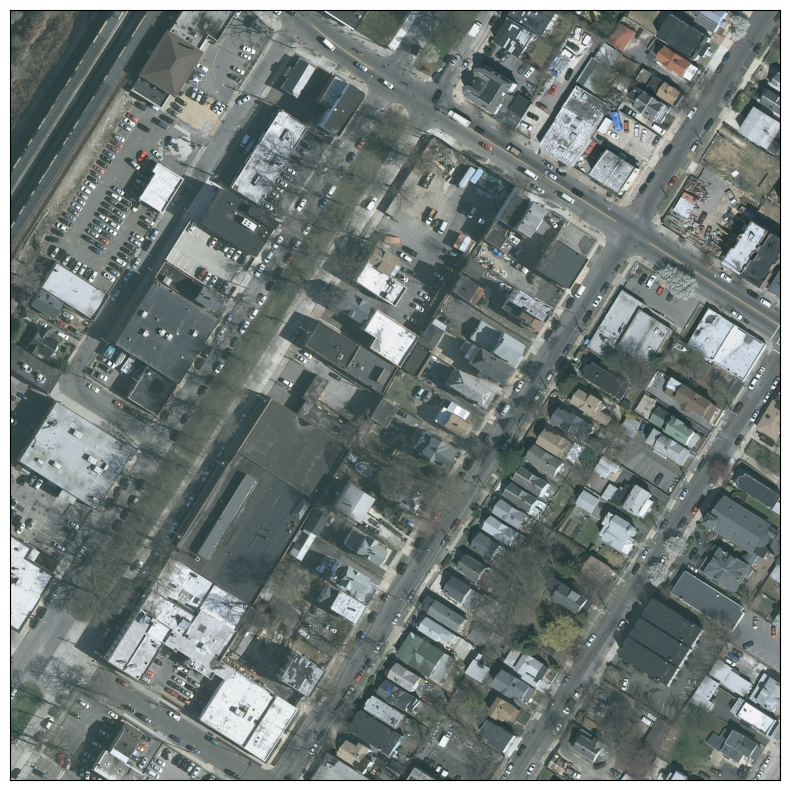

<Axes: >

In [10]:
import earthpy.plot as ep
ep.plot_rgb(image.to_numpy(), rgb=(0,1,2))

In [83]:
import rioxarray

# Open just one file
ds = rioxarray.open_rasterio(r"E:\Datasets\Imagenes Satelitales\New York City\NYC Images\22\000135.jp2")

print(f"Data Type: {ds.dtype}")
print(f"Min Value: {ds.min().item()}")
print(f"Max Value: {ds.max().item()}")

Data Type: uint8
Min Value: 0
Max Value: 255
